# Семинар 1: Свертка изображений
...на датасете MNIST


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
%matplotlib inline

## 1. Учимся работать с картинками средствами **Python**, **NumPy** и **PyTorch**

### Загружаем изображение с диска

Image format: JPEG; shape: (640, 427); color scheme: RGB


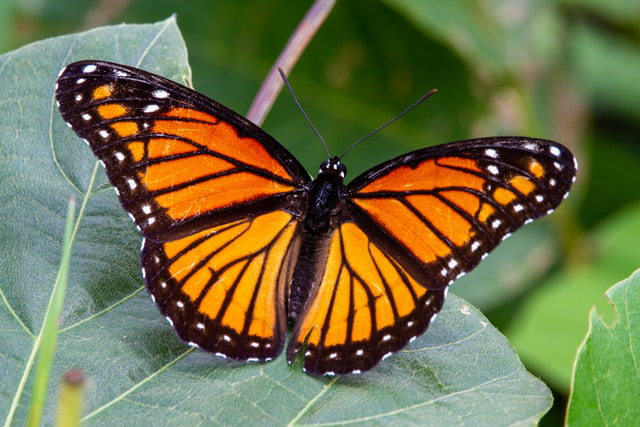

In [2]:
# !pip install Pillow
from PIL import Image

img = Image.open("static/butterfly.jpg")
print(f"Image format: {img.format}; shape: {img.size}; color scheme: {img.mode}")
img

### Матричное представление изображения

Мы знаем, что цветное изображение состоит из 3 числовых матриц или трехмерного тензора. Каждая матрица соответствует одному из 3 базовых цветов: красному, зеленому и синему.

Image array shape: (427, 640, 3)


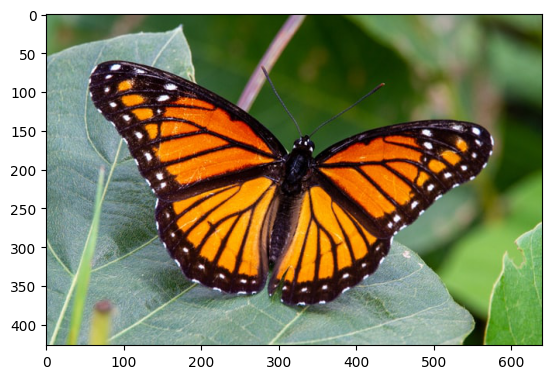

In [3]:
# преобразуем изображение в массив
img_matrix = np.array(img)

# (высота, ширина, число каналов)
print(f"Image array shape: {img_matrix.shape}")

plt.imshow(img_matrix)
plt.show()

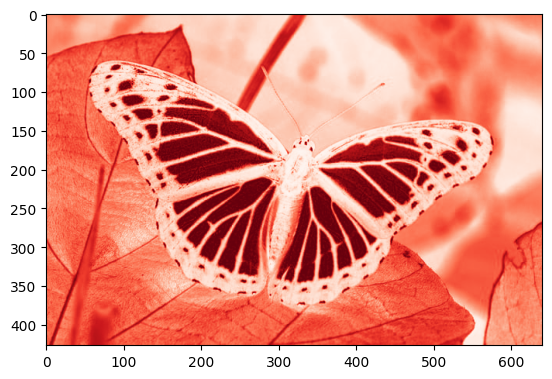

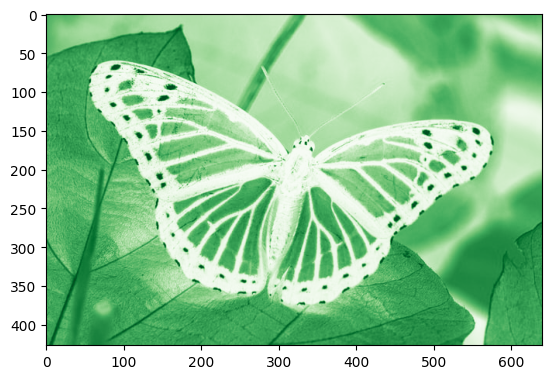

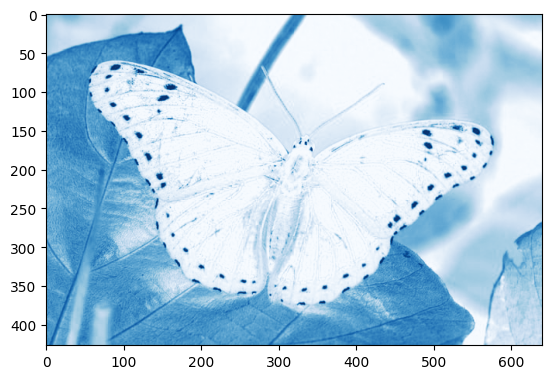

In [4]:
# посмотрим на все каналы изображения отдельно
plt.imshow(img_matrix[:, :, 0], cmap=cm.Reds)
plt.show()

plt.imshow(img_matrix[:, :, 1], cmap=cm.Greens)
plt.show()

plt.imshow(img_matrix[:, :, 2], cmap=cm.Blues)
plt.show()

## 2. Применяем константные свёртки к изображениям

### Класс torch.nn.Conv2d

In [5]:
import torch.nn as nn

nn.Conv2d

torch.nn.modules.conv.Conv2d

В **PyTorch** свёрточный слой представлен в модуле `torch.nn` классом [`Conv2d`](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html) с параметрами:
- `in_channels`: количество входных каналов 
- `out_channels`: количество выходных каналов 
- `kernel_size`: размер ядра 
- `stride`: шаг 
- `padding`: паддинг 
- `padding_mode`: режим паддинга  (`'zeros'`, `'reflect'` и др.)
- `dilation`: растяжение 

#### `kernel_size`

**Размер ядра**. `int`, если ядро квадратное и кортеж из двух чисел, если ядро прямоугольное. Задает размер фильтра, с которым производится свёртка изображения.

**`kernel_size=3`**

![no_padding_no_strides.gif](static/no_padding_no_strides.gif)

Эта и следующие анимации взяты [здесь](https://github.com/vdumoulin/conv_arithmetic).

#### `stride`

**Шаг**. Задает шаг, в пикселях, на который сдвигается фильтр. `int`, если по горизонтали и вертикали сдвигается на одно и то же число. Кортеж из двух чисел, если сдвиги разные.

**`stride=2`**

![no_padding_strides.gif](static/no_padding_strides.gif)

#### `padding`

**Паддинг**. Количество пикселей, которыми дополняется изображение. Аналогично шагу и размеру ядра, может быть, как `int`, так и кортежем из двух чисел.

**`padding=1`**

![same_padding_no_strides.gif](static/same_padding_no_strides.gif)

### Свёртка изображений

Чем может быть полезна свертка при работе с изображениями? Свертки детектируют **паттерны на картинках** – цвета и сочетания цветов, небольшие объекты. Обычно значения свертки являются обучаемыми параметрами нейрости. Однако существуют "готовые" свертки, настроенные на определенные паттерны.

Например, оператор Собеля (свертка с определенными параметрами) используется для детекции границ на изображении. Применим этот оператор. Для этого пока не будем пользоваться классом `torch.nn.Conv2d`, а возьмём соответствующую функцию из модуля `torch.nn.functional`. 

In [6]:
import torch

# В этом модуле примерно все те же самые операторы, что и в `torch.nn`,
# но только представлениы они не в виде классов, а виде функций.
from torch.nn.functional import conv2d

Конвертируем изображение в тензор и переставим размерности в порядке `(batch_size, n_channels, height, width)`, который принят в **PyTorch**.

In [7]:
img_matrix.shape

(427, 640, 3)

In [8]:
img_tensor = torch.tensor(img_matrix, dtype=torch.float)
img_tensor = img_tensor.permute(2, 0, 1).unsqueeze(0)
img_tensor.size()

torch.Size([1, 3, 427, 640])

Зададим оператор Собеля для детектирования горизонтальных границ

In [9]:
sobel_hor = [
    [-1, -2, -1], 
    [0, 0, 0], 
    [1, 2, 1]
]

kernel = [[sobel_hor, sobel_hor, sobel_hor]]
kernel = torch.tensor(kernel, dtype=torch.float)
kernel.size()

torch.Size([1, 3, 3, 3])

In [10]:
# свернём картинку с подготовленным ядром свёртки
img_conv_hor = conv2d(img_tensor, kernel)
img_conv_hor = img_conv_hor.permute(0, 2, 3, 1)
img_conv_hor.size()

torch.Size([1, 425, 638, 1])

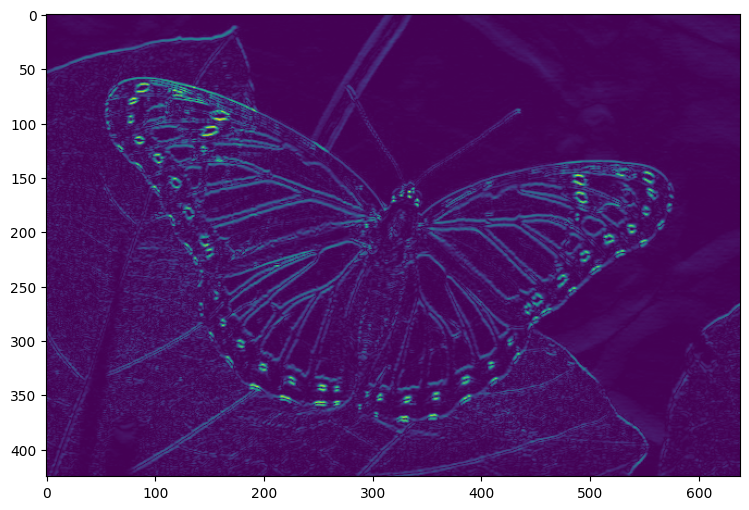

In [11]:
plt.figure(figsize=(1.5 * 7, 1.5 * 4))
plt.imshow(torch.abs(img_conv_hor[0, :, :, 0]))
plt.show()

Проделаем то же самое для детектирования вертикальных границ

In [12]:
sobel_ver = [
    [-1, 0, 1], 
    [-2, 0, 2], 
    [-1, 0, 1]
]

# одна матрица на каждый канал картинки
kernel = [[sobel_ver, sobel_ver, sobel_ver]]
kernel = torch.tensor(kernel, dtype=torch.float)

img_conv_ver = conv2d(img_tensor, kernel)

img_conv_ver = img_conv_ver.permute(0, 2, 3, 1)
img_conv_ver.size()

torch.Size([1, 425, 638, 1])

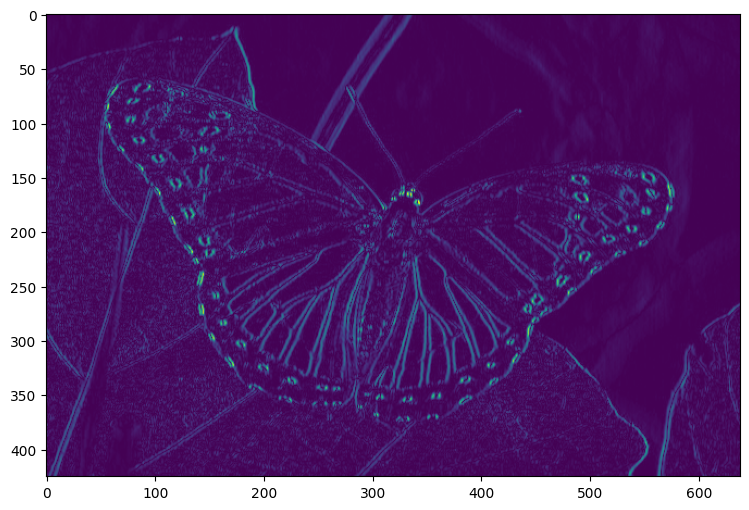

In [13]:
plt.figure(figsize=(1.5 * 7, 1.5 * 4))
plt.imshow(torch.abs(img_conv_ver[0, :, :, 0]))
plt.show()

Объединим два изображения

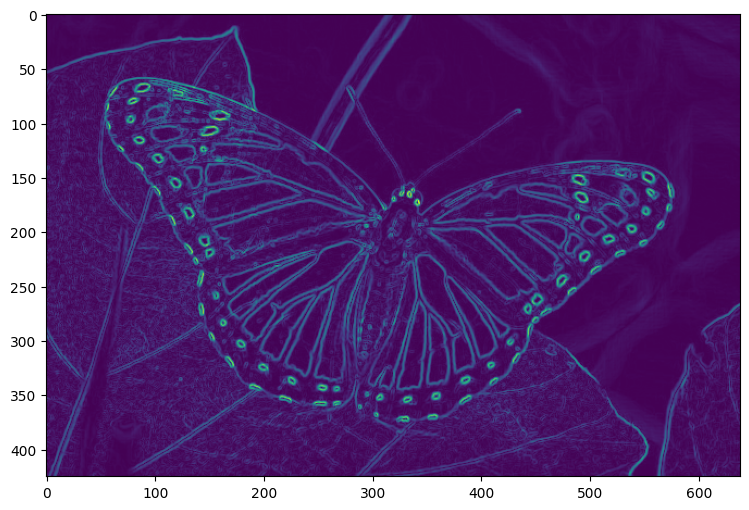

In [14]:
img_conv = torch.sqrt(img_conv_ver**2 + img_conv_hor**2)

plt.figure(figsize=(1.5 * 7, 1.5 * 4))
plt.imshow(img_conv[0, :, :, 0])
plt.show()

### Задание 1
По аналогии с примером выше, сверните изображение со случайным ядром такого же размера. Например blur

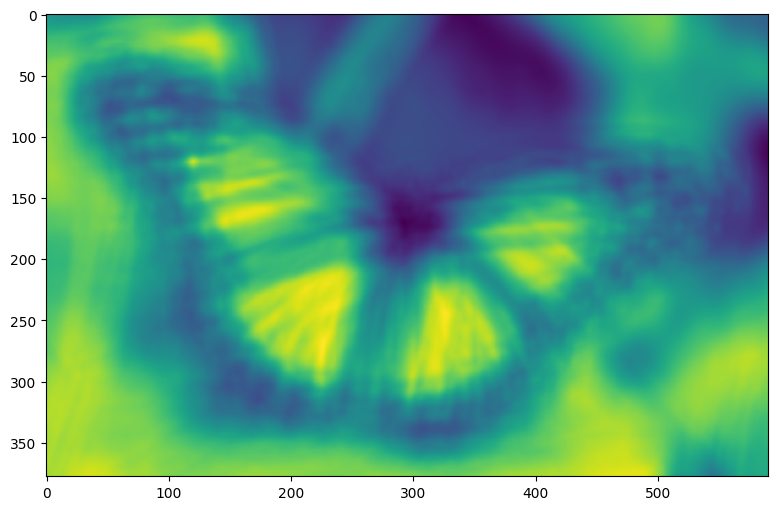

In [17]:
### YOUR CODE HERE
kernel = img_tensor[:, :, 120:170, 120:170]
img_conv_random = conv2d(img_tensor, kernel)
img_conv_random  = img_conv_random.permute(0,2,3,1)



# рисуем результат
plt.figure(figsize=(1.5 * 7, 1.5 * 4))
plt.imshow(torch.abs(img_conv_random[0, :, :, 0]))
plt.show()

### Сравниваем работу полносвязных и свёрточных сетей на датасете MNIST

Сначала решим задачу классификации изображений полносвязной нейронной сетью из прошлого семинара.

In [18]:
import torch.nn.functional as F
import torchvision
from torch import nn

Скачаем и подготовим уже знакомые нам данные для классификации.

In [19]:
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST

In [20]:
transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.1307,), (0.3081,)),
    ]
)

mnist_train = MNIST(
    "./mnist/", train=True, download=True, transform=transform
)
mnist_val = MNIST(
    "./mnist/", train=False, download=True, transform=transform
)


train_dataloader = DataLoader(mnist_train, batch_size=64, shuffle=True)
val_dataloader = DataLoader(mnist_val, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:11<00:00, 845kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 104kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 788kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 230kB/s]


Подготовим цикл обучения.

In [21]:
def train(model, optimizer, n_epochs=5):
    """Функция, в которой проходит обучение нейросети.

    Parameters
    ----------
    model : nn.Module
        Нейросеть для обучения.
    optimizer : torch.optim.Optimizer
        Алгоритм оптимизации гиперпараметров (например, SGD)
    n_epochs : int, default 5
        Количество эпох для обучения нейросети. Эпоха – проход по объектам
        датасета алгоритмом оптимизации с обновлением гиперпараметров.
    
    """
    # подключаем wandb

    for epoch in range(n_epochs):
        # тренировка
        for x_train, y_train in tqdm(train_dataloader):
            y_pred = model(x_train)
            loss = F.cross_entropy(y_pred, y_train)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        # валидация
        if epoch % 2 == 0:
            val_loss = []
            val_accuracy = []

            # отключается весь функционал расчета градиентов
            with torch.no_grad():
                for x_val, y_val in tqdm(val_dataloader):
                    y_pred = model(x_val)
                    loss = F.cross_entropy(y_pred, y_val)
                    val_loss.append(loss.numpy())
                    val_accuracy.extend(
                        (torch.argmax(y_pred, dim=-1) == y_val).numpy().tolist()
                    )

            
            print(
                f"Epoch: {epoch}, loss: {np.mean(val_loss)}, accuracy: {np.mean(val_accuracy)}"
            )

Обучим полносвязную архитектуру.

In [22]:
model = nn.Sequential(
    nn.Flatten(),  # превращаем картинку 28х28 в вектор размером 784
    nn.Linear(
        28 * 28, 128
    ),  # линейный слой, преобразующий вектор размера 784 в вектор размера 128
    nn.ReLU(),  # нелинейность
    nn.Linear(
        128, 10
    ),  # линейный слой, преобразующий вектор размера 128 в вектор размера 10
)

optimizer = torch.optim.SGD(
    model.parameters(), lr=0.01
)  # создаем оптимизатор и передаем туда параметры модели

In [23]:
print(
    f"Training model with {sum([x[1].numel() for x in model.named_parameters()])} parameters"
)
train(model, optimizer)

Training model with 101770 parameters


  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

Epoch: 0, loss: 0.3172316551208496, accuracy: 0.9125


  0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch: 2, loss: 0.2252974808216095, accuracy: 0.9362


  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

Epoch: 4, loss: 0.18126578629016876, accuracy: 0.9493


Изменим архитектуру, добавив в неё свёрточные слои.

In [24]:
model = nn.Sequential(
    nn.Conv2d(
        in_channels=1, out_channels=10, kernel_size=5
    ),  # добавим свёрточный слой с 10 ядрами
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=4),  # уменьшим картинку в 4 раза по каждой стороне
    nn.Flatten(),  # превращаем картинку 6х6х10 в вектор размером 360
    nn.Linear(
        6 * 6 * 10, 128
    ),  # линейный слой, преобразующий вектор размера 360 в вектор размера 128
    nn.ReLU(),  # нелинейность
    nn.Linear(
        128, 10
    ),  # отображение в пространство размерности числа меток классификации
)

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [25]:
print(
    f"Training model with {sum([x[1].numel() for x in model.named_parameters()])} parameters"
)
train(model, optimizer)

Training model with 47758 parameters


  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

Epoch: 0, loss: 0.19728296995162964, accuracy: 0.9449


  0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch: 2, loss: 0.1050226241350174, accuracy: 0.9692


  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

Epoch: 4, loss: 0.07422058284282684, accuracy: 0.9766


### Задание 2

По аналогии с предыдущим примером, обучите нейронную сеть, у которой будут следующие слои:

- Свёрточный слой с 10 ядрами размером 5
- Функция активации ReLU
- Уменьшить картинку в 2 раза (по каждому измерению)
- Свёрточный слой с 20 ядрами размером 5
- Функция активации ReLU
- Уменьшить картинку в 2 раза (по каждому измерению)
- Полносвязный слой со 128 нейронами
- Функция активации ReLU
- Выходной слой

Напишите решение двумя способами:
 - с помощью класса `nn.Sequential`
 - в виде наследника класса `torch.nn.Module`

In [29]:
# 1-й способ
model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=10, kernel_size=5),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Conv2d(in_channels=10, out_channels=20, kernel_size=5),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Flatten(),
    nn.Linear(4 * 4 * 20, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

In [30]:
# 2-й способ
class ConvNetMNIST(nn.Module):

    def __init__(self):
        """Создание объекта класса. Через дополнительные аргументы можно
        изменять параметры слоев сети."""
        # инициализируем родителя
        super().__init__()

        # записываем в атрибуты составные части сети
        self.conv_1 = nn.Conv2d(in_channels=1, out_channels=10, kernel_size=5)
        self.conv_2 = nn.Conv2d(in_channels=10, out_channels=20, kernel_size=5)
        self.relu = nn.ReLU()  # используется 3 раза
        self.pool = nn.MaxPool2d(kernel_size=2)  # используется 2 раза
        self.flatten = nn.Flatten()
        self.fc_1 = nn.Linear(4 * 4 * 20, 128)
        self.fc_2 = nn.Linear(128, 10)

    def forward(self, x : torch.tensor) -> torch.tensor:
        """Прямой проход по нейронной сети. Вычисление предсказаний."""
        ### YOUR CODE HERE
        pred = self.conv_1(x)
        pred = self.relu(pred)
        pred = self.pool(pred)
        pred = self.conv_2(pred)
        pred = self.relu(pred)
        pred = self.pool(pred)
        pred = self.flatten(pred)
        pred = self.fc_1(pred)
        pred = self.relu(pred)
        pred = self.fc_2(pred)

        return pred
    
model = ConvNetMNIST()


Код, написанный первым способом, более краткий и легче читается. Однако не все архитектуры можно представить в виде последовательного применения операторов из `torch.nn`. Также некоторые операторы могут повторяться. Поэтому чаще нейросеть записывается именно вторым способом, с помощью класса-наследника `nn.Module`.

In [31]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
print(
    f"Training model with {sum([x[1].numel() for x in model.named_parameters()])} parameters"
)

train(model, optimizer)

Training model with 47658 parameters


  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

Epoch: 0, loss: 0.1717105656862259, accuracy: 0.9519


  0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch: 2, loss: 0.07785365730524063, accuracy: 0.9756


  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

Epoch: 4, loss: 0.055215101689100266, accuracy: 0.9817


### Задание 3. В одном из вариантов stride
Stride - это: 
- меньше операций (один слой вместо двух)
- сохраняется возможность обучения (веса обучаются)
- меньше гиперпараметров

#### Старый способ:
x = conv3×3(x, stride=1)  # 224→224

x = maxpool2×2(x)         # 224→112

#### Новый способ:
x = conv3×3(x, stride=2)  # 224→112 сразу!

In [39]:
model = nn.Sequential(
    # Первая свертка (без изменений)
    # Output: (1, 28, 28) -> (10, 24, 24)
    nn.Conv2d(in_channels=1, out_channels=10, kernel_size=5),
    nn.ReLU(),
    
    # Вместо MaxPool2d используем вторую свертку с dilation=2
    # Это увеличит рецептивное поле без потери разрешения через пулинг
    # Чтобы сохранить размер 4x4 на выходе при входном 24x24, 
    # используем dilation=4 и kernel_size=5
    nn.Conv2d(in_channels=10, out_channels=20, kernel_size=5, dilation=4),
    nn.ReLU(),
    
    nn.Flatten(),
    # Размер входа в Linear зависит от итогового размера карты признаков.
    # При 28x28 на входе -> после Conv1 (24x24) -> после Conv2 dilation=4 (8x8)
    # Итого: 8 * 8 * 20 = 1280
    nn.Linear(8 * 8 * 20, 128), 
    nn.ReLU(),
    nn.Linear(128, 10)
)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
print(
    f"Training model with {sum([x[1].numel() for x in model.named_parameters()])} parameters"
)

train(model, optimizer)

Training model with 170538 parameters


  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

Epoch: 0, loss: 0.2636168301105499, accuracy: 0.9234


  0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch: 2, loss: 0.1307794451713562, accuracy: 0.9609


  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

Epoch: 4, loss: 0.10078921169042587, accuracy: 0.9705


In [35]:
# Задание 3
model = nn.Sequential(
    nn.Conv2d(
        in_channels=1, out_channels=10, kernel_size=5, dilation=2 # 20*20*10
    ),
    nn.ReLU(),
    nn.Conv2d(
        in_channels=10, out_channels=20, kernel_size=5, dilation=2 # 12*12*20
    ),
    nn.Flatten(),
    nn.Linear(
        12 * 12 * 20, 128
    ),
    nn.ReLU(),
    nn.Linear(
        128, 10
    ),
)

train(model, optimizer)

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

Epoch: 0, loss: 2.293383836746216, accuracy: 0.1324


  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch: 2, loss: 2.293383836746216, accuracy: 0.1324


  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

Epoch: 4, loss: 2.293383836746216, accuracy: 0.1324


In [37]:
model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=10, kernel_size=5),
    nn.ReLU(),
    nn.Conv2d(in_channels=10, out_channels=20, kernel_size=5),
    nn.Flatten(),
    nn.Linear(in_features=4*4*20, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=10)
)

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
print(
    f"Training model with {sum([x[1].numel() for x in model.named_parameters()])} parameters"
)

train(model, optimizer)

Training model with 47658 parameters


  0%|          | 0/938 [00:00<?, ?it/s]

RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x8000 and 320x128)

In [ ]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
print(
    f"Training model with {sum([x[1].numel() for x in model.named_parameters()])} parameters"
)

train(model, optimizer)

Training model with 170538 parameters


  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

Epoch: 0, loss: 0.2628837525844574, accuracy: 0.9241


  0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch: 2, loss: 0.1424611359834671, accuracy: 0.9558


  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

Epoch: 4, loss: 0.08467606455087662, accuracy: 0.9744


In [36]:
model = nn.Sequential(
    nn.Conv2d(
        in_channels=1, out_channels=10, kernel_size=5, dilation=2 
    ),
    nn.ReLU(),
    nn.Conv2d(
        in_channels=10, out_channels=20, kernel_size=5, dilation=2
    ),
    nn.ReLU(),
    nn.Flatten(),  
    nn.Linear(
        12*12*20, 128
    ),
    nn.ReLU(),
    nn.Linear(128,10)
)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
print(
    f"Training model with {sum([x[1].numel() for x in model.named_parameters()])} parameters"
)

train(model, optimizer)

Training model with 375338 parameters


  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

Epoch: 0, loss: 0.2648342251777649, accuracy: 0.9272


  0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch: 2, loss: 0.09981851279735565, accuracy: 0.9692


  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

Epoch: 4, loss: 0.06909693032503128, accuracy: 0.9788
